In [140]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import scipy.io
import torcwa
from tqdm.notebook import tqdm
from pvlib import spectrum
from refractiveindex import RefractiveIndexMaterial
%load_ext line_profiler

def get_sine_eps(x,params,grating_period,eps):
    """Generate sine grating permittivity profile.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        params (torch.Tensor): list of amplitude and phase shift. shape (n,2), where n is n*2*np.pi/grating_period'th frequency.
        eps (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 1D tensor of permittivity profile.
    """
    A = torch.sum(params[:,0])
    cosines = torch.cos(2.*np.pi*torch.arange(1, params.shape[0]+1, 
                                              dtype=geo_dtype,device=device).unsqueeze(1)*(x.unsqueeze(0)/grating_period)
                                               - params[:,1].unsqueeze(1))
    cosines = cosines * params[:,0].unsqueeze(1)
    eps = 1 + (eps-1)*(0.5*(A+torch.sum(cosines, dim=0))/A)
    return eps.unsqueeze(1)   # make shape (nx,1) so add_layer accepts it

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
inc_ang = 0.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian
spectra = spectrum.get_reference_spectra()
am15g = spectra['global']
wavelengths = torch.arange(350,1110,10,dtype=geo_dtype,device=device)  # nm
sun_weights = torch.tensor(am15g[wavelengths.cpu().numpy()].to_numpy())

# material
si = RefractiveIndexMaterial(shelf='main', book='Si', page='Green-2008')
si_eps = torch.tensor(si.get_refractive_index(wavelengths.cpu().numpy()) +
                      1j * si.get_extinction_coefficient(wavelengths.cpu().numpy()))**2

# geometry
h = 1000 #nm
grating_period = 1000 # nm
L = [grating_period, 1.]  # Å
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-h,1.5*h,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()
n_wavelength = 2

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [141]:
# Generate and perform simulation
params = torch.tensor([[0.,0.],[0.1,np.pi],[0.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
sim.solve_global_smatrix()

In [150]:
#The true incident input power is not necessarily 0.5, depending on the polarization state and the incident angle and azimuthal angle.
#This is a bit weird, but is how rcwa works. The input polarization amplitude directly sets the E field amplitudes of the incoming waves, 
# IN FOURIER SPACE, and the actual power carried by these waves depends on the E->H transform (which depends on angle, wavelength, etc).

#polarization = [np.sqrt(2)/2.,np.sqrt(2)/2.]  # x and y components
#polarization = [0.,1.] # y-polarized
polarization = [1.,0.] # x-polarized

sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
E_i = sim.E_i                       # shape (2*order_N,1), complex
Vi  = sim.Vi                         # E->H transform for input half-space

H_i = torch.matmul(Vi, E_i)          # H Fourier amplitudes for incoming waves

Ex = E_i[:sim.order_N,0]             # Ex per order
Ey = E_i[sim.order_N:,0]             # Ey per order
Hx = H_i[:sim.order_N,0]             # Hx per order
Hy = H_i[sim.order_N:,0]             # Hy per order

# time-averaged Poynting flux through z - summed over all fourier components (per unit cell)
Pz = 0.5 * torch.real(torch.sum(Ex * torch.conj(Hy) - Ey * torch.conj(Hx)))
x_samples = torcwa.rcwa_geo.x 
P_inc = torch.trapz(Pz*torch.ones_like(x_samples), x_samples)

print('Incident power (per unit cell) =', Pz.item())
print('Expected power (per unit cell) =', 0.5 * (torch.abs(torch.tensor(polarization[0]))**2 + torch.abs(torch.tensor(polarization[1]))**2).item())
print(f'line-integrated incident power density = {P_inc.item():.4f}')
reflectance = sim.S_parameters(orders=[0,0],direction='forward',port='reflection',polarization='xx',ref_order=[0,0])
print(f'Zeroth-order reflectance = {(torch.abs(reflectance)**2).item():.4f}')
transmission = sim.S_parameters(orders=[0,0],direction='forward',port='transmission',polarization='xx',ref_order=[0,0])
print(f'Zeroth-order transmission = {(torch.abs(transmission)**2).item():.4f}')
print(f'Absorbed power total = {(1 - torch.abs(reflectance)**2 - torch.abs(transmission)**2).item():.4f}')

Incident power (per unit cell) = 0.5
Expected power (per unit cell) = 0.5
line-integrated incident power density = 499.9000
Zeroth-order reflectance = 0.5885
Zeroth-order transmission = 0.0000
Absorbed power total = 0.4115


In [148]:
# choose probe planes (just above / below film). use same device dtype as sim
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)

# request fields at both planes: x_axis is your x sampling (1D tensor), y0 is y coordinate (often 0)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(torcwa.rcwa_geo.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

# Ex,Hy shapes: (nx, 2)  (nx across x, 2 planes)
S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

# integrate over x to get power (per unit cell). Integrate using trapezoid rule.
x_cpu = torcwa.rcwa_geo.x.cpu().numpy()
S_cpu = S_z.cpu().numpy()
P_top = np.trapezoid(S_cpu[:,0], x_cpu)
P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
P_air = np.trapezoid(S_cpu[:,2], x_cpu)
P_absorbed_film = P_top - P_bot
P_absorbed_grating = P_air - P_top

print('Sanity check: power conservation and absorption by Poynting flux')
print('P_in  (top)   =', P_top)
print('P_out (bottom)=', P_bot)
print('P_absorbed (film) =', P_absorbed_film)
print('P_absorbed (grating) =', P_absorbed_grating)
print('P_air (z=0)   =', P_air)
print(f'Absorptance by Poynting flux in film = {P_absorbed_film / P_inc:.4f}')
print(f'Absorptance by Poynting flux in grating = {P_absorbed_grating / P_inc:.4f}')
print()

Sanity check: power conservation and absorption by Poynting flux
P_in  (top)   = 204.96416
P_out (bottom)= 8.808324e-31
P_absorbed (film) = 204.96416
P_absorbed (grating) = 0.7571869
P_air (z=0)   = 205.72134
Absorptance by Poynting flux in film = 0.4100
Absorptance by Poynting flux in grating = 0.0015



In [27]:
# sampling (increase for better convergence)
n_samples = 500

x_vol = torch.linspace(0, grating_period, n_samples, device=device, dtype=geo_dtype)          # (nx,)
nz_film = n_samples
nz_grat = n_samples
sine_sample = get_sine_eps(x_vol,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])

z_film = torch.linspace(A, A + h, nz_film, device=device, dtype=geo_dtype)   # film region
z_grat = torch.linspace(0.0, A, nz_grat, device=device, dtype=geo_dtype)     # grating region

# get fields
[Ex_f, Ey_f, Ez_f], _ = sim.field_xz(x_vol, z_film, torch.tensor(0., device=device, dtype=geo_dtype))
[Ex_g, Ey_g, Ez_g], _ = sim.field_xz(x_vol, z_grat, torch.tensor(0., device=device, dtype=geo_dtype))

# squared field magnitude
En2_f = torch.abs(Ex_f)**2 + torch.abs(Ey_f)**2 + torch.abs(Ez_f)**2   # (nx, nz_film)
En2_g = torch.abs(Ex_g)**2 + torch.abs(Ey_g)**2 + torch.abs(Ez_g)**2   # (nx, nz_grat)

# angular freq (LH units: c=1 so freq = 1/λ; wavelength variable is in nm)
omega = 2.0 * torch.pi / wavelength.to(device=device, dtype=geo_dtype)   # tensor scalar

# film permittivity (complex) and imaginary part
eps_film = si_eps[n_wavelength].to(device=device, dtype=torch.complex64)
eps_im_f = torch.imag(eps_film)   # scalar

# grating permittivity (x-dependent)
eps_grat = sine_sample.squeeze(1).to(device=device, dtype=torch.complex64)   # (nx,)
eps_im_g = torch.imag(eps_grat).unsqueeze(1)   # (nx,1) , will broadcast over z

# local power density: 0.5 * omega * Im(eps) * |E|^2  (Heaviside-Lorentz units)
pdens_f = 0.5 * omega * eps_im_f * En2_f    # (nx, nz_film)
pdens_g = 0.5 * omega * eps_im_g * En2_g    # (nx, nz_grat)

# integrate over x then z (per unit cell)
Px_f = torch.trapz(pdens_f, x=x_vol, dim=0)        # (nz_film,)
Pvol_f = torch.trapz(Px_f, x=z_film, dim=0)        # scalar

Px_g = torch.trapz(pdens_g, x=x_vol, dim=0)        # (nz_grat,)
Pvol_g = torch.trapz(Px_g, x=z_grat, dim=0)        # scalar

# bring to CPU scalars for comparison
Pvol_f_val = Pvol_f.cpu().item()
Pvol_g_val = Pvol_g.cpu().item()

# Poynting computed earlier: P_absorbed_film, P_absorbed_grating (from previous cell)
print(f"Poynting film (P_top - P_bot)       = {P_absorbed_film:.6e}")
print(f"Volume integral film                  = {Pvol_f_val:.6e}")
print(f"Relative error (film)                 = {(Pvol_f_val - P_absorbed_film)/P_absorbed_film:.3e}")

print(f"Poynting grating (P_air - P_top)     = {P_absorbed_grating:.6e}")
print(f"Volume integral grating               = {Pvol_g_val:.6e}")
print(f"Relative error (grating)              = {(Pvol_g_val - P_absorbed_grating)/P_absorbed_grating:.3e}")

Poynting film (P_top - P_bot)       = 2.761144e+03
Volume integral film                  = 3.531267e+03
Relative error (film)                 = 2.789e-01
Poynting grating (P_air - P_top)     = 1.155151e+01
Volume integral grating               = 1.155182e+01
Relative error (grating)              = 2.642e-05


  0%|          | 0/30 [00:00<?, ?it/s]

C:\Users\andre\AppData\Local\Temp\ipykernel_5696\3552769105.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


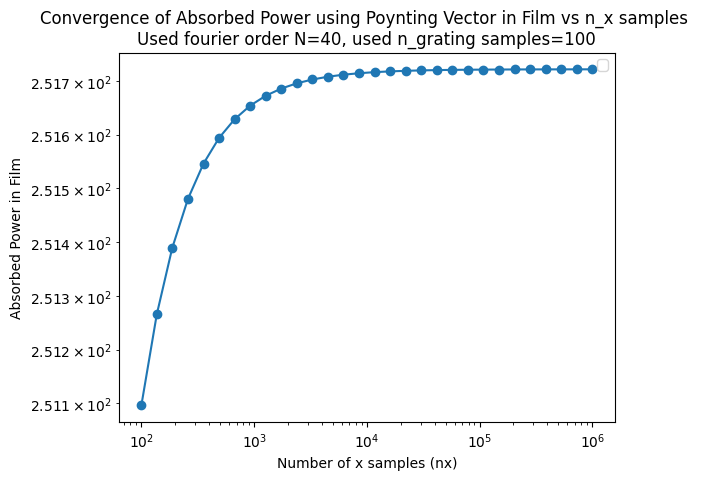

In [28]:
#Do a bunch of convergence checks by varying first n_samples in poynting vector integration
P_absorbed_film_list0 = []
order_N = 40
nx_list = np.logspace(2,6,30,dtype=int)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order = [order_N,0]
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)         # (nx,)
for nx_test in tqdm(nx_list):
    torcwa.rcwa_geo.nx = 100
    torcwa.rcwa_geo.grid()

    sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
    #torcwa.rcwa_geo.nx = nx_test
    #torcwa.rcwa_geo.grid()
    sample_x = torcwa.rcwa_geo
    sample_x.nx = nx_test
    sample_x.grid()
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(sample_x.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_cpu = sample_x.x.cpu().numpy()
    S_cpu = S_z.cpu().numpy()
    P_top = np.trapezoid(S_cpu[:,0], x_cpu)
    P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
    P_air = np.trapezoid(S_cpu[:,2], x_cpu)
    P_absorbed_film = P_top - P_bot
    P_absorbed_grating = P_air - P_top
    P_absorbed_film_list0.append(P_absorbed_film)

plt.plot(nx_list, P_absorbed_film_list0, marker='o')
plt.xlabel('Number of x samples (nx)')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
plt.xscale('log')
#plt.vlines(x=5000,ymin=1.712*10, ymax=1.718*10, color='r', linestyle='--', label='nx=5000')
#plt.ylim(1.712*10, 1.718*10)
#plt.xlim(60,2e6)
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs n_x samples \nUsed fourier order N={order_N}, used n_grating samples=100')
plt.legend()
plt.show()

In [18]:
P_absorbed_film_list0[-1]

np.float32(31.168789)

  0%|          | 0/30 [00:00<?, ?it/s]

C:\Users\andre\AppData\Local\Temp\ipykernel_5696\3896004232.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


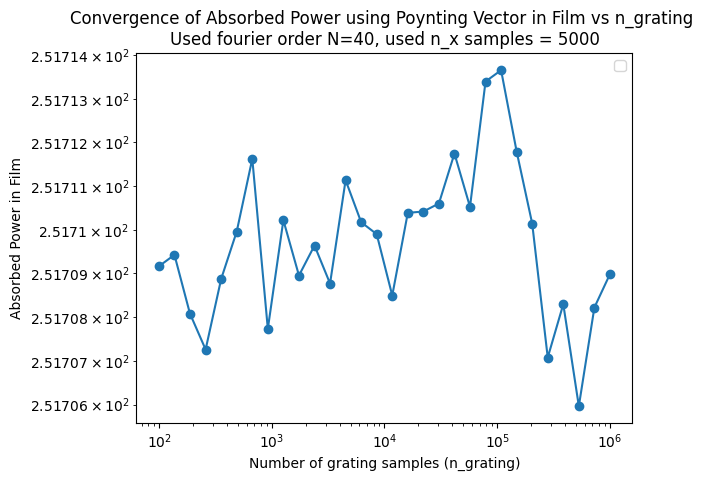

In [29]:
#Do a bunch of convergence checks then varying n_grating in poynting vector integration
P_absorbed_film_list1 = []
order_N = 40
nx_list = np.logspace(2,6,30,dtype=int)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order = [order_N,0]
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)
for nx_test in tqdm(nx_list):
    torcwa.rcwa_geo.nx = nx_test
    torcwa.rcwa_geo.grid()

    sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

    sample_x = torcwa.rcwa_geo
    sample_x.nx = 5000
    sample_x.grid()
    x_samples = sample_x.x
    
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_samples, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_cpu = x_samples.cpu().numpy()
    S_cpu = S_z.cpu().numpy()
    P_top = np.trapezoid(S_cpu[:,0], x_cpu)
    P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
    P_air = np.trapezoid(S_cpu[:,2], x_cpu)
    P_absorbed_film = P_top - P_bot
    P_absorbed_grating = P_air - P_top
    P_absorbed_film_list1.append(P_absorbed_film)

plt.plot(nx_list, P_absorbed_film_list1, marker='o')
plt.xlabel('Number of grating samples (n_grating)')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
plt.xscale('log')
#plt.vlines(x=100,ymin=1.71757*10, ymax=1.71773*10, color='r', linestyle='--', label='n_grating=100')
#plt.ylim(1.71757*10, 1.71773*10)
#plt.xlim(60,2e6)
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs n_grating \nUsed fourier order N={order_N}, used n_x samples = {sample_x.nx}')
plt.legend()
plt.show()

In [ ]:
P_absorbed_film_list1[-1]

  0%|          | 0/35 [00:00<?, ?it/s]

C:\Users\andre\AppData\Local\Temp\ipykernel_5696\3119024652.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed nx samples = 5000, Used n_grating = 100')

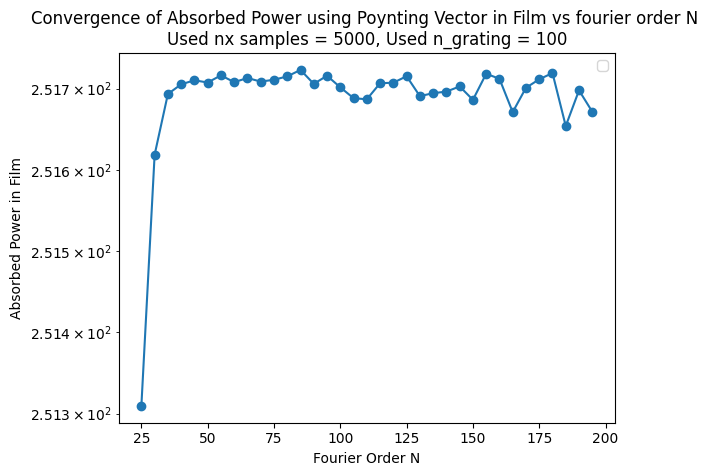

In [30]:
P_absorbed_film_list2 = []
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
Order_N_list = np.arange(25,200,5)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)

for order_N in tqdm(Order_N_list):
    torcwa.rcwa_geo.nx = 100
    torcwa.rcwa_geo.grid()
    order = [order_N,0]
    sine_eps = get_sine_eps(x_samples,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

    sample_x = torcwa.rcwa_geo
    sample_x.nx = 5000
    sample_x.grid()
    x_samples = sample_x.x
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_samples, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_cpu = x_samples.cpu().numpy()
    S_cpu = S_z.cpu().numpy()
    P_top = np.trapezoid(S_cpu[:,0], x_cpu)
    P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
    P_air = np.trapezoid(S_cpu[:,2], x_cpu)
    P_absorbed_film = P_top - P_bot
    P_absorbed_grating = P_air - P_top
    P_absorbed_film_list2.append(P_absorbed_film)

plt.plot(Order_N_list, P_absorbed_film_list2, marker='o')
plt.xlabel('Fourier Order N')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
#plt.vlines(x=40,ymin=1.713e1,ymax=1.718e1, color='r', linestyle='--', label='N=40')
#plt.ylim(1.713e1,1.718e1)
plt.legend()
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed nx samples = {sample_x.nx}, Used n_grating = {100}')

In [ ]:
P_absorbed_film_list2[-1]

In [31]:
# sampling (increase for better convergence)
n_samples_list = [500, 1000, 2000, 3000]#, 4000, 5000, 7000, 10000]
P_absorbed_film_list3 = []


torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
sim.solve_global_smatrix()
sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')


for n_samples in tqdm(n_samples_list):
    x_vol = torch.linspace(0, grating_period, n_samples, device=device, dtype=geo_dtype)          # (nx,)
    nz_film = n_samples
    sine_sample = get_sine_eps(x_vol,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])

    z_film = torch.linspace(A, A + h, nz_film, device=device, dtype=geo_dtype)   # film region


    # get fields
    [Ex_f, Ey_f, Ez_f], _ = sim.field_xz(x_vol, z_film, torch.tensor(0., device=device, dtype=geo_dtype))


    # squared field magnitude
    En2_f = torch.abs(Ex_f)**2 + torch.abs(Ey_f)**2 + torch.abs(Ez_f)**2   # (nx, nz_film)

    # angular freq (LH units: c=1 so freq = 1/λ; wavelength variable is in nm)
    omega = 2.0 * torch.pi / wavelength.to(device=device, dtype=geo_dtype)   # tensor scalar

    # film permittivity (complex) and imaginary part
    eps_film = si_eps[n_wavelength].to(device=device, dtype=torch.complex64)
    eps_im_f = torch.imag(eps_film)   # scalar

    # local power density: 0.5 * omega * Im(eps) * |E|^2  (Heaviside-Lorentz units)
    pdens_f = 0.5 * omega * eps_im_f * En2_f    # (nx, nz_film)
    # integrate over x then z (per unit cell)
    Px_f = torch.trapz(pdens_f, x=x_vol, dim=0)        # (nz_film,)
    Pvol_f = torch.trapz(Px_f, x=z_film, dim=0)        # scalar

    # bring to CPU scalars for comparison
    Pvol_f_val = Pvol_f.cpu().item()
    P_absorbed_film_list3.append(Pvol_f_val)




  0%|          | 0/4 [00:00<?, ?it/s]

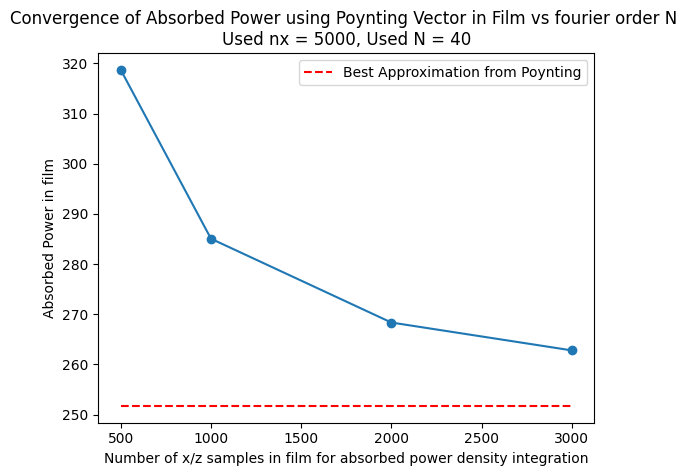

In [32]:
plt.plot(n_samples_list, P_absorbed_film_list3, marker='o')
plt.xlabel('Number of x/z samples in film for absorbed power density integration')
plt.ylabel('Absorbed Power in film')
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed nx = {torcwa.rcwa_geo.nx}, Used N = {order_N}')
plt.hlines(y=P_absorbed_film_list0[-1], xmin=n_samples_list[0], xmax=n_samples_list[-1], color='r', linestyle='--', label='Best Approximation from Poynting')
plt.legend()
plt.show()

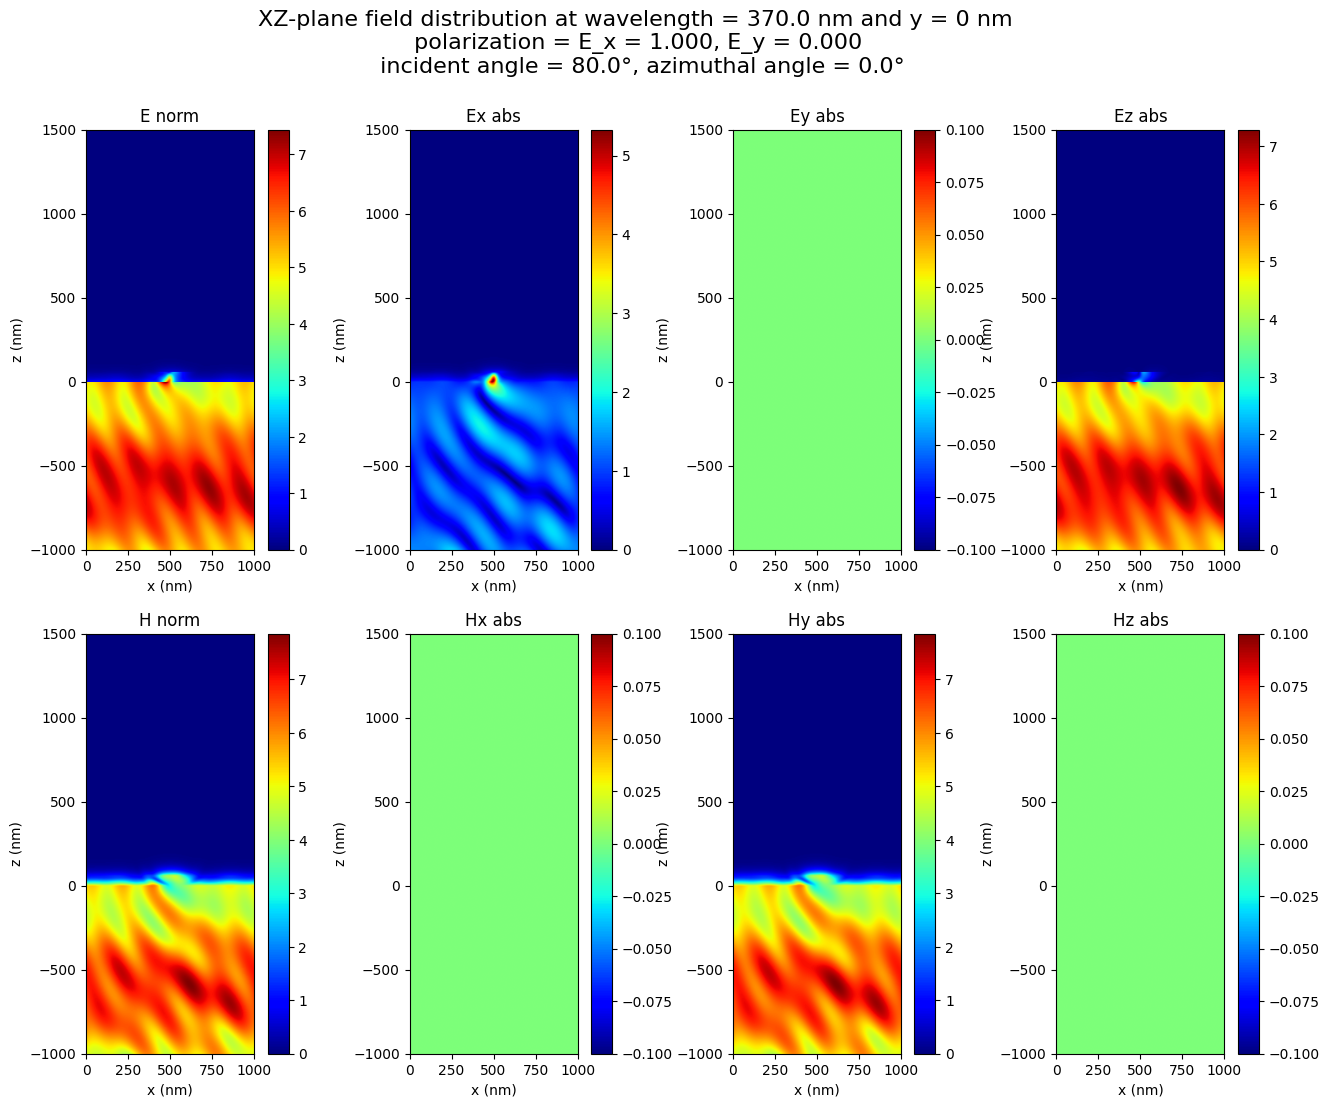

In [34]:
# Define simulation again
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
sim.solve_global_smatrix()
sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

# View XZ-plane fields
x_plot = torch.linspace(0, L[0], 500, device=device)
z_plot = torch.linspace(-h, 1.5*h, 500, device=device)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_plot,z_plot,torch.tensor(0))
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)
x_plot = x_plot.cpu()
z_plot = z_plot.cpu()

fig, axes = plt.subplots(figsize=(16,12),nrows=2,ncols=4)
im0 = axes[0,0].imshow(torch.transpose(Enorm,-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,0].set(title='E norm',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im1 = axes[0,1].imshow(torch.transpose(torch.abs(Ex),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,1].set(title='Ex abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im2 = axes[0,2].imshow(torch.transpose(torch.abs(Ey),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,2].set(title='Ey abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im3 = axes[0,3].imshow(torch.transpose(torch.abs(Ez),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,3].set(title='Ez abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im4 = axes[1,0].imshow(torch.transpose(Hnorm,-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,0].set(title='H norm',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im5 = axes[1,1].imshow(torch.transpose(torch.abs(Hx),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,1].set(title='Hx abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im6 = axes[1,2].imshow(torch.transpose(torch.abs(Hy),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,2].set(title='Hy abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im7 = axes[1,3].imshow(torch.transpose(torch.abs(Hz),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,3].set(title='Hz abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
fig.colorbar(im0,ax=axes[0,0])
fig.colorbar(im1,ax=axes[0,1])
fig.colorbar(im2,ax=axes[0,2])
fig.colorbar(im3,ax=axes[0,3])
fig.colorbar(im4,ax=axes[1,0])
fig.colorbar(im5,ax=axes[1,1])
fig.colorbar(im6,ax=axes[1,2])
fig.colorbar(im7,ax=axes[1,3])
fig.suptitle(f'XZ-plane field distribution at wavelength = {wavelength} nm and y = 0 nm \n polarization = E_x = {polarization[0]:.3f}, E_y = {polarization[1]:.3f} \n incident angle = {inc_ang*180/np.pi:.1f}°, azimuthal angle = {azi_ang*180/np.pi:.1f}°', fontsize=16)
plt.show()

In [ ]:
plt.plot(x_axis,sine_eps.real.cpu(),label='Sine grating eps real')
plt.plot(x_axis,sine_eps.imag.cpu(),label='Sine grating eps imag')
plt.legend()

In [ ]:
# verify linearity of fields vs nonlinearity of norms
x_plot = torch.linspace(0, L[0], 300, device=device)
z_plot = torch.linspace(-h, 1.5*h, 300, device=device)
# get fields for x and y polarizations
sim.source_planewave(amplitude=[1.,0.], direction='forward', notation='xy')
[Ex_x, Ey_x, Ez_x], [Hx_x, Hy_x, Hz_x] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

sim.source_planewave(amplitude=[0.,1.], direction='forward', notation='xy')
[Ex_y, Ey_y, Ez_y], [Hx_y, Hy_y, Hz_y] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

# direct diagonal
a = 1/np.sqrt(2)
sim.source_planewave(amplitude=[a,a], direction='forward', notation='xy')
[Ex_d, Ey_d, Ez_d], [Hx_d, Hy_d, Hz_d] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

# check linear superposition of complex fields
Ex_sum = a*Ex_x + a*Ex_y
Ey_sum = a*Ey_x + a*Ey_y
Ez_sum = a*Ez_x + a*Ez_y

print('max abs error Ex:', torch.max(torch.abs(Ex_sum - Ex_d)).item())
print('max abs error Ey:', torch.max(torch.abs(Ey_sum - Ey_d)).item())
print('max abs error Ez:', torch.max(torch.abs(Ez_sum - Ez_d)).item())

# check norms (not linear)
Enorm_sum = 0.5*(torch.sqrt(torch.abs(Ex_x)**2 + torch.abs(Ey_x)**2 + torch.abs(Ez_x)**2) +
                 torch.sqrt(torch.abs(Ex_y)**2 + torch.abs(Ey_y)**2 + torch.abs(Ez_y)**2))
Enorm_diag = torch.sqrt(torch.abs(Ex_d)**2 + torch.abs(Ey_d)**2 + torch.abs(Ez_d)**2)
print('Note that the norms are not linearly additive:')
print(f'mean(Enorm_sum - Enorm_diag) = {torch.mean(Enorm_sum - Enorm_diag).item():.6e}')